In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
nc_path = r'D:\05-Finale runs\geneva_50m\t330.nc'

In [3]:
ds = xr.open_dataset(nc_path)

In [4]:
resolution = 50

In [5]:
ds['XC'] = np.array(range(0,len(ds['XC'])))*resolution + resolution/2
ds['YC'] = np.array(range(0,len(ds['YC'])))*resolution + resolution/2
ds['XG'] = np.array(range(0,len(ds['XG'])))*resolution
ds['YG'] = np.array(range(0,len(ds['YG'])))*resolution

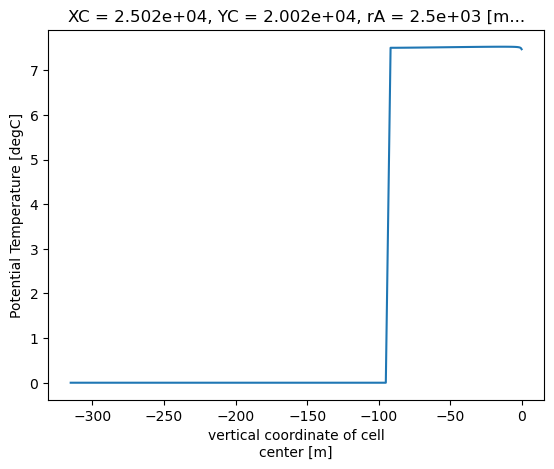

In [6]:
ds.isel(XC=500, YC=400).THETA.plot()
plt.show()

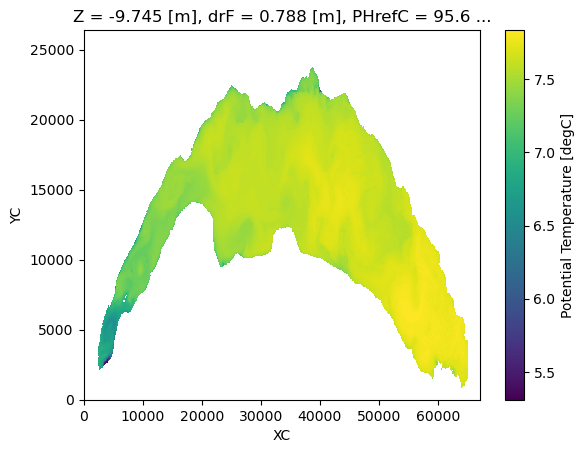

In [16]:
plt.close()
plt.figure()
ds.THETA.where(ds.THETA != 0).isel(Z=15).plot()
plt.show()

In [17]:
def plot_map(ds, z: int):
    plt.ioff()
    plt.close()
    fig, ax = plt.subplots(figsize=(15,6))

    T_plot = ds['time'].values
    Z_plot = ds['Z'].values[z]
    xr_plot = ds['THETA'].isel(Z=z)
    xr_plot = xr_plot.where(xr_plot != 0, np.nan)
    xr_plot.plot(cmap='jet')
    plt.axis('equal')

    subsetting_factor = 10
    X_trimmed = ds['XC'][::subsetting_factor]
    Y_trimmed = ds['YC'][::subsetting_factor]
    U_trimmed = ds['UVEL'].isel(Z=z)[:,1:][::subsetting_factor,::subsetting_factor]
    V_trimmed = ds['VVEL'].isel(Z=z)[1:,:][::subsetting_factor,::subsetting_factor]

    U_trimmed = U_trimmed.where(U_trimmed != 0, np.nan)
    V_trimmed = V_trimmed.where(V_trimmed != 0, np.nan)
    plt.quiver(X_trimmed, Y_trimmed, U_trimmed, V_trimmed, scale=7)

    plt.text(0.02, 0.98, f'{np.datetime_as_string(T_plot, unit="s").replace("T", " ")}', transform=plt.gca().transAxes, ha='left', va='top')
    plt.text(0.02, 0.9, f'Z={Z_plot}m', transform=plt.gca().transAxes, ha='left', va='top')
    plt.title('')

    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_title("")
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)

    return plt.gcf()

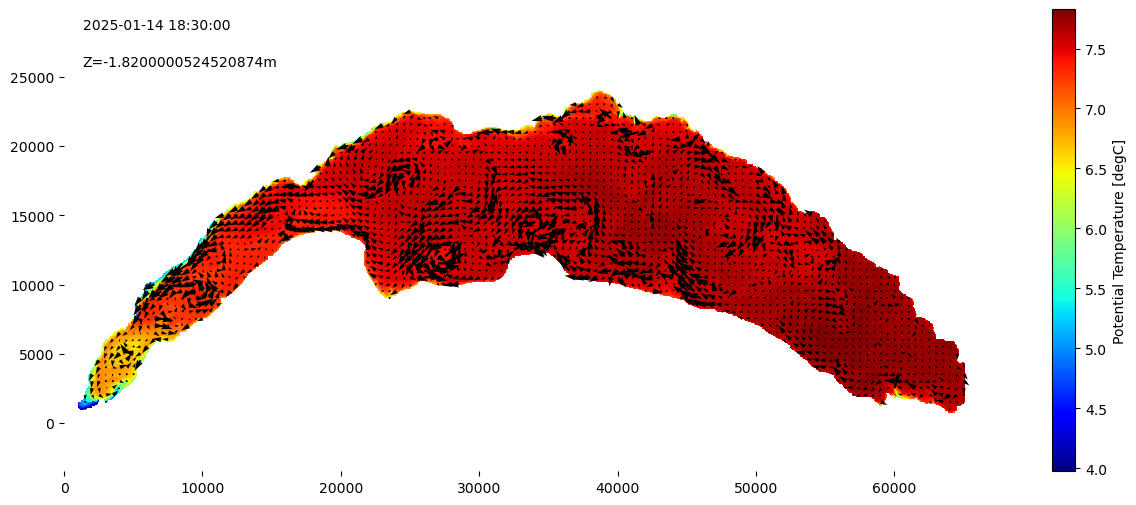

In [24]:
plot_map(ds, 3)